# Real-Time Dynamics

This notebook starts from a converged stationary state and evolves it in real time with the unitary version of the split-step method. The most useful example is an electric-field quench: load a ground state relaxed at `E=0`, then switch on a finite electric field during real-time propagation.


In [13]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.gp2d_split_step import GPParameters, gaussian_spinor, make_grid, normalize, x_wall_potential, evolve_imaginary, split_step_real_time
from src.observables import energy_functional, chemical_potential, currents, find_curve_crossings
from src.plotting import configure_matplotlib, plot_density, plot_current_panels, plot_energy_branches, animate_density
from src.io_utils import load_npz, save_state

configure_matplotlib(use_tex=False)
print(f"Repository root: {ROOT}")


Repository root: c:\Users\hugob\OneDrive\Escritorio\Memoria  TFG Final\spinor-gp-split-step


## Choose the Real-Time Configuration


In [14]:
# Input state. By default this is a stationary state relaxed at E=0.
STATE_PATH = ROOT / "data" / "example_states" / "ground_state_split_step_B1_g50_E0_Lx0.5.npz"

# Real-time parameters. Use None to keep the value stored in the .npz file.
REAL_TIME_G = None
REAL_TIME_B = None
REAL_TIME_E = 0.5      # Electric-field quench: E=0 in the state, E=0.5 in real time.
REAL_TIME_V0 = None
REAL_TIME_WALL_FRACTION_X = None
REAL_TIME_WALL_STEEPNESS = None

# Grid overrides. Keep as None unless you know the saved state was built on a different grid.
REAL_TIME_LX = None
REAL_TIME_LY = None
REAL_TIME_N = None

# Evolution and animation controls.
RUN_REAL_TIME = False
DT = 2e-3
N_STEPS = 1500
SAVE_EVERY = 20
ANIMATION_INTERVAL = 45
COMPONENT = "total"  # "total", "up" or "down"
OUTPUT_GIF = ROOT / "results" / "videos" / "evolucion_tiempo_real.gif"

def value_from_data(data, key, default):
    return float(data[key]) if key in data else default

data = load_npz(STATE_PATH)
grid = make_grid(
    Lx=REAL_TIME_LX if REAL_TIME_LX is not None else value_from_data(data, "Lx", 5.0),
    Ly=REAL_TIME_LY if REAL_TIME_LY is not None else value_from_data(data, "Ly", 5.0),
    N=REAL_TIME_N if REAL_TIME_N is not None else int(data.get("N", 128)),
)
psi = normalize(data["psi"], grid)

saved_V0 = float(data["V0"]) if "V0" in data else float(data.get("V_0", 100.0))
params = GPParameters(
    g=REAL_TIME_G if REAL_TIME_G is not None else value_from_data(data, "g", 50.0),
    B=REAL_TIME_B if REAL_TIME_B is not None else value_from_data(data, "B", 1.0),
    E=REAL_TIME_E if REAL_TIME_E is not None else value_from_data(data, "E", 0.0),
    V0=REAL_TIME_V0 if REAL_TIME_V0 is not None else saved_V0,
    wall_fraction_x=(
        REAL_TIME_WALL_FRACTION_X
        if REAL_TIME_WALL_FRACTION_X is not None
        else value_from_data(data, "wall_fraction_x", 0.5)
    ),
    wall_steepness=(
        REAL_TIME_WALL_STEEPNESS
        if REAL_TIME_WALL_STEEPNESS is not None
        else value_from_data(data, "wall_steepness", 9.0)
    ),
)
potential = x_wall_potential(grid, params)

print("Loaded:", STATE_PATH)
print(f"Real-time parameters: g={params.g}, B={params.B}, E={params.E}, V0={params.V0}")
print("Initial norm:", np.sum(np.abs(psi)**2) * grid.dx * grid.dy)


Loaded: c:\Users\hugob\OneDrive\Escritorio\Memoria  TFG Final\spinor-gp-split-step\data\example_states\ground_state_split_step_B1_g50_E0_Lx0.5.npz
Real-time parameters: g=50.0, B=1.0, E=0.5, V0=100.0
Initial norm: 1.0


## Real-Time Split-Step Evolution

Real-time evolution uses the same splitting structure as imaginary time, but with unitary factors $e^{-iH\Delta t}$. The cell is disabled by default so the notebook opens quickly on GitHub. Set `RUN_REAL_TIME=True` above to generate new frames with the selected physical parameters.


In [15]:
def density_for_animation(psi, component="total"):
    if component == "up":
        return np.abs(psi[0])**2
    if component == "down":
        return np.abs(psi[1])**2
    return np.sum(np.abs(psi)**2, axis=0)

frames = []
if RUN_REAL_TIME:
    norm_history = []
    time_history = []
    for step in range(N_STEPS + 1):
        if step % SAVE_EVERY == 0:
            frames.append(density_for_animation(psi, COMPONENT))
            norm_history.append(np.sum(np.abs(psi)**2) * grid.dx * grid.dy)
            time_history.append(step * DT)
        psi = split_step_real_time(psi, grid, params, DT, potential=potential)

    fig, ax = plt.subplots(figsize=(5, 3.2), constrained_layout=True)
    ax.plot(time_history, norm_history)
    ax.set_xlabel("time")
    ax.set_ylabel("norm")
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print("Real-time evolution skipped. Set RUN_REAL_TIME=True in the configuration cell to generate frames.")


Real-time evolution skipped. Set RUN_REAL_TIME=True in the configuration cell to generate frames.


## Animation

If `RUN_REAL_TIME=True`, the following cell displays the newly generated animation and can save it using Matplotlib writers. Otherwise, it displays the precomputed electric-field-quench GIF included in `results/videos/`.


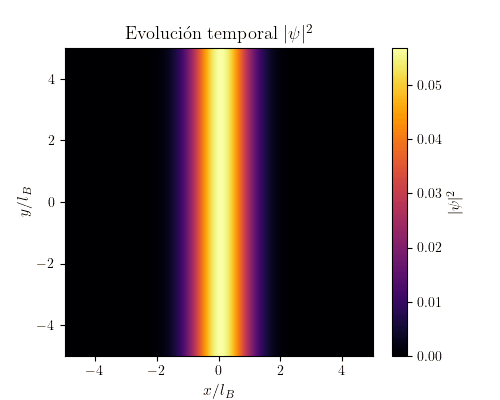

In [16]:
from IPython.display import HTML, Image, display

if frames:
    ani = animate_density(frames, grid, interval=ANIMATION_INTERVAL)
    display(HTML(ani.to_jshtml()))
    # Uncomment to save the new animation.
    # ani.save(OUTPUT_GIF, dpi=160)
elif OUTPUT_GIF.exists():
    display(Image(filename=str(OUTPUT_GIF)))
else:
    print("No frames and no precomputed GIF found.")
